# Modeling: U.S. Inflation Forecasting

This notebook estimates traditional time series models and machine learning models for forecasting U.S. year-over-year CPI inflation.

Important change in this version:

- Time series models use **expanding one-step-ahead forecasts**.
- ARIMA/ARIMAX/SARIMA/SARIMAX are estimated on the training set, then applied to the full observed series using fixed training-set parameters (`apply(refit=False)`).
- VAR is estimated on the training set, then forecasts one step ahead using the latest observed history.
- This makes the comparison fairer against the Naive forecast, Ridge, and XGBoost, which also use only lagged information available before the forecast date.

In [ ]:
# =========================
# 1. Imports and settings
# =========================

from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available. Install it with: pip install xgboost")

BASE_DIR = Path(".")
OUTPUT_DIR = BASE_DIR / "model_outputs_rolling"
OUTPUT_DIR.mkdir(exist_ok=True)

START_DATE = "1990-01-01"
END_DATE = "2026-04-01"
TRAIN_END = "2018-12-01"
TEST_START = "2019-01-01"
MAX_ML_LAG = 12
VAR_MAX_LAGS = 8
RUN_SEASONAL_MODELS = True
RANDOM_STATE = 42

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: C:\Users\ADMIN\Desktop\Project Timeseries\model_outputs_rolling


## 2. Load or rebuild processed data

The notebook first tries to load:

- `processed_macro_1990_2026.csv`
- `processed_macro_lagged_1990_2026.csv`

If these files are not available or do not have the expected structure, the notebook rebuilds the processed datasets from the raw FRED CSV files.

In [2]:
# =========================
# 2. Data loading helpers
# =========================

def read_fred_csv(filename, value_col):
    path = BASE_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {filename}")
    df = pd.read_csv(path)
    date_col = "observation_date" if "observation_date" in df.columns else "date"
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.rename(columns={date_col: "date"})
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    return df[["date", value_col]]


def load_processed_file(filename):
    path = BASE_DIR / filename
    if not path.exists():
        return None
    df = pd.read_csv(path)
    # Try to identify date column or index column.
    possible_date_cols = ["date", "observation_date", "DATE", "Unnamed: 0"]
    date_col = next((c for c in possible_date_cols if c in df.columns), None)
    if date_col is not None:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.rename(columns={date_col: "date"}).set_index("date")
    else:
        try:
            df.index = pd.to_datetime(df.index)
        except Exception:
            pass
    df = df.sort_index()
    return df


def build_processed_data():
    # Prefer updated files if available.
    cpi_file = "CPIAUCSL_update.csv" if (BASE_DIR / "CPIAUCSL_update.csv").exists() else "CPIAUCSL.csv"
    unrate_file = "UNRATE_update.csv" if (BASE_DIR / "UNRATE_update.csv").exists() else "UNRATE.csv"
    fed_file = "FEDFUNDS.csv"
    indpro_file = "INDPRO.csv"

    cpi = read_fred_csv(cpi_file, "CPIAUCSL")
    unrate = read_fred_csv(unrate_file, "UNRATE")
    fed = read_fred_csv(fed_file, "FEDFUNDS")
    indpro = read_fred_csv(indpro_file, "INDPRO")

    raw = cpi.merge(unrate, on="date", how="outer")
    raw = raw.merge(fed, on="date", how="outer")
    raw = raw.merge(indpro, on="date", how="outer")
    raw = raw.set_index("date").sort_index()
    raw = raw.loc[START_DATE:END_DATE].asfreq("MS")

    # Fill isolated missing values, if any, while preserving monthly frequency.
    # Forward fill is used as a leakage-safe fallback because it only uses past information.
    missing_before = raw.isna().sum()
    if missing_before.sum() > 0:
        print("Missing values before forward fill:")
        print(missing_before[missing_before > 0])
    raw = raw.ffill()
    missing_after = raw.isna().sum()
    if missing_after.sum() > 0:
        print("Missing values remaining after forward fill:")
        print(missing_after[missing_after > 0])

    raw["inflation"] = 100 * (np.log(raw["CPIAUCSL"]) - np.log(raw["CPIAUCSL"].shift(12)))
    raw["IP_growth"] = 100 * (np.log(raw["INDPRO"]) - np.log(raw["INDPRO"].shift(12)))

    model_data = raw[["inflation", "UNRATE", "FEDFUNDS", "IP_growth"]].dropna().copy()

    ml_data = model_data.copy()
    for col in ["inflation", "UNRATE", "FEDFUNDS", "IP_growth"]:
        for lag in range(1, MAX_ML_LAG + 1):
            ml_data[f"{col}_lag_{lag}"] = ml_data[col].shift(lag)
    ml_data = ml_data.dropna().copy()

    model_data.to_csv(BASE_DIR / "processed_macro_1990_2026.csv")
    ml_data.to_csv(BASE_DIR / "processed_macro_lagged_1990_2026.csv")
    return model_data, ml_data


model_data = load_processed_file("processed_macro_1990_2026.csv")
ml_data = load_processed_file("processed_macro_lagged_1990_2026.csv")

expected_cols = {"inflation", "UNRATE", "FEDFUNDS", "IP_growth"}
if model_data is None or not expected_cols.issubset(set(model_data.columns)):
    print("Processed files not found or invalid. Rebuilding from raw FRED CSV files...")
    model_data, ml_data = build_processed_data()
else:
    model_data = model_data[list(expected_cols)].sort_index()
    if ml_data is None or "inflation" not in ml_data.columns:
        print("Lagged processed file not found or invalid. Rebuilding lagged features...")
        ml_data = model_data.copy()
        for col in ["inflation", "UNRATE", "FEDFUNDS", "IP_growth"]:
            for lag in range(1, MAX_ML_LAG + 1):
                ml_data[f"{col}_lag_{lag}"] = ml_data[col].shift(lag)
        ml_data = ml_data.dropna().copy()
        ml_data.to_csv(BASE_DIR / "processed_macro_lagged_1990_2026.csv")

model_data = model_data.loc[START_DATE:END_DATE].sort_index()
ml_data = ml_data.loc[START_DATE:END_DATE].sort_index()

print("model_data shape:", model_data.shape)
print("ml_data shape:", ml_data.shape)
display(model_data.head())
display(model_data.tail())

model_data shape: (424, 4)
ml_data shape: (412, 52)


,UNRATE,IP_growth,FEDFUNDS,inflation
date,,,,
1991-01-01,6.4,-0.966112,6.91,5.493372
1991-02-01,6.6,-2.611770,6.25,5.176193
1991-03-01,6.8,-3.685794,6.12,4.708539
1991-04-01,6.7,-3.159955,5.91,4.697834
1991-05-01,6.9,-2.526630,5.78,4.912208


,UNRATE,IP_growth,FEDFUNDS,inflation
date,,,,
2025-12-01,4.4,1.182094,3.72,2.618715
2026-01-01,4.3,1.398267,3.64,2.363060
2026-02-01,4.4,0.985834,3.64,2.404854
2026-03-01,4.3,0.754860,3.64,3.233124
2026-04-01,4.3,1.344065,3.64,3.709582


## 3. Train-test split

The main test period is January 2019 to April 2026. All forecasts are evaluated on this out-of-sample period.

In [3]:
# =========================
# 3. Train-test split
# =========================

train_data = model_data.loc[:TRAIN_END].copy()
test_data = model_data.loc[TEST_START:].copy()

ml_train = ml_data.loc[:TRAIN_END].copy()
ml_test = ml_data.loc[TEST_START:].copy()

print("Training data:", train_data.index.min().date(), "to", train_data.index.max().date(), train_data.shape)
print("Testing data:", test_data.index.min().date(), "to", test_data.index.max().date(), test_data.shape)
print("ML training data:", ml_train.shape)
print("ML testing data:", ml_test.shape)

config = {
    "start_date": START_DATE,
    "end_date": END_DATE,
    "train_end": TRAIN_END,
    "test_start": TEST_START,
    "max_ml_lag": MAX_ML_LAG,
    "var_max_lags": VAR_MAX_LAGS,
    "run_seasonal_models": RUN_SEASONAL_MODELS,
    "run_xgboost": XGBOOST_AVAILABLE,
    "model_data_shape": list(model_data.shape),
    "train_shape": list(train_data.shape),
    "test_shape": list(test_data.shape),
}
with open(OUTPUT_DIR / "model_config.json", "w") as f:
    json.dump(config, f, indent=2)

Training data: 1991-01-01 to 2018-12-01 (336, 4)
Testing data: 2019-01-01 to 2026-04-01 (88, 4)
ML training data: (324, 52)
ML testing data: (88, 52)


## 4. Stationarity checks and ACF/PACF diagnostics

This section adds standard time-series diagnostics before model estimation. The ADF test uses the null hypothesis of a unit root, while the KPSS test uses the null hypothesis of stationarity. The tests are run on the training set to avoid using information from the test period when making modeling decisions.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16708\3709897106.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, _ = kpss(series, regression="c", nlags="auto")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16708\3709897106.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, _ = kpss(series, regression="c", nlags="auto")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16708\3709897106.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, kpss_lags, _ = kpss(series, regression="c", nlags="auto")


,Variable,ADF Statistic,ADF p-value,ADF Used Lag,ADF n_obs,ADF Conclusion 5pct,KPSS Statistic,KPSS p-value,KPSS Used Lag,KPSS Conclusion 5pct,Combined Conclusion
0,Inflation,-3.471170,0.008759,16,319,Reject unit root,0.778625,0.010000,10,Reject stationarity,Mixed evidence
1,Unemployment Rate,-2.495360,0.116607,6,329,Fail to reject unit root,0.273821,0.100000,11,Fail to reject stationarity,Mixed evidence
2,Federal Funds Rate,-2.032991,0.272298,11,324,Fail to reject unit root,1.824175,0.010000,11,Reject stationarity,Likely non-stationary
3,Industrial Production Growth,-3.036758,0.031601,15,320,Reject unit root,0.348106,0.099523,11,Fail to reject stationarity,Likely stationary


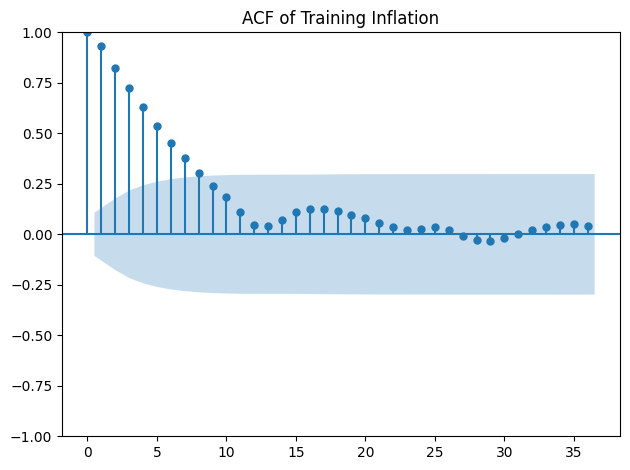

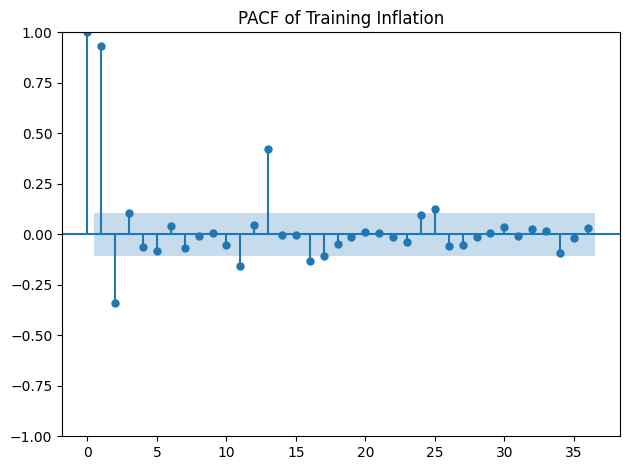

In [4]:
# =========================
# 4. Stationarity checks
# =========================

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


def run_stationarity_tests(series, name):
    series = pd.Series(series).dropna()

    # ADF null: the series has a unit root / is non-stationary.
    adf_stat, adf_p, adf_lags, adf_nobs, *_ = adfuller(series, autolag="AIC")

    # KPSS null: the series is stationary.
    try:
        kpss_stat, kpss_p, kpss_lags, _ = kpss(series, regression="c", nlags="auto")
    except Exception as e:
        kpss_stat, kpss_p, kpss_lags = np.nan, np.nan, np.nan

    if adf_p < 0.05 and (pd.isna(kpss_p) or kpss_p >= 0.05):
        combined = "Likely stationary"
    elif adf_p >= 0.05 and (pd.isna(kpss_p) or kpss_p < 0.05):
        combined = "Likely non-stationary"
    else:
        combined = "Mixed evidence"

    return {
        "Variable": name,
        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "ADF Used Lag": adf_lags,
        "ADF n_obs": adf_nobs,
        "ADF Conclusion 5pct": "Reject unit root" if adf_p < 0.05 else "Fail to reject unit root",
        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS Used Lag": kpss_lags,
        "KPSS Conclusion 5pct": "Reject stationarity" if pd.notna(kpss_p) and kpss_p < 0.05 else "Fail to reject stationarity",
        "Combined Conclusion": combined,
    }

stationarity_results = pd.DataFrame([
    run_stationarity_tests(train_data["inflation"], "Inflation"),
    run_stationarity_tests(train_data["UNRATE"], "Unemployment Rate"),
    run_stationarity_tests(train_data["FEDFUNDS"], "Federal Funds Rate"),
    run_stationarity_tests(train_data["IP_growth"], "Industrial Production Growth"),
])

display(stationarity_results)
stationarity_results.to_csv(OUTPUT_DIR / "stationarity_tests.csv", index=False)

# ACF and PACF plots for the target variable.
fig = plot_acf(train_data["inflation"].dropna(), lags=36)
plt.title("ACF of Training Inflation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "acf_inflation.png", dpi=200)
plt.show()

fig = plot_pacf(train_data["inflation"].dropna(), lags=36, method="ywm")
plt.title("PACF of Training Inflation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pacf_inflation.png", dpi=200)
plt.show()


## 4. Helper functions

In [5]:
# =========================
# 4. Helper functions
# =========================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_forecast(y_true, y_pred):
    y_true, y_pred = y_true.align(y_pred, join="inner")
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "n_obs": len(y_true),
    }


def select_sarimax_order(y_train, exog_train=None, max_p=3, d_values=(0, 1), max_q=3):
    # Select a small ARIMA order by AIC on the training set.
    best_order = None
    best_aic = np.inf
    results = []
    for d in d_values:
        for p in range(max_p + 1):
            for q in range(max_q + 1):
                if p == 0 and q == 0:
                    continue
                order = (p, d, q)
                try:
                    model = SARIMAX(
                        y_train,
                        exog=exog_train,
                        order=order,
                        trend="c",
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    res = model.fit(disp=False, maxiter=200)
                    results.append((order, res.aic))
                    if res.aic < best_aic:
                        best_aic = res.aic
                        best_order = order
                except Exception:
                    continue
    if best_order is None:
        best_order = (1, 0, 1)
    return best_order, pd.DataFrame(results, columns=["order", "AIC"]).sort_values("AIC")


def one_step_sarimax_apply(y_train, y_full, forecast_start, forecast_end, order, seasonal_order=(0, 0, 0, 0), exog_train=None, exog_full=None, label="model"):
    # Fast one-step-ahead forecasts with fixed training-set parameters.
    # The model is estimated on the training sample, then the fitted parameters are
    # applied to the full observed series. In-sample predictions in the test period
    # are interpreted as one-step-ahead forecasts conditional on information through t-1.
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=order,
        seasonal_order=seasonal_order,
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False, maxiter=300)
    if exog_full is not None:
        applied = res.apply(y_full, exog=exog_full, refit=False)
    else:
        applied = res.apply(y_full, refit=False)
    pred = applied.get_prediction(start=forecast_start, end=forecast_end, dynamic=False).predicted_mean
    pred.name = label
    return pred, res

def plot_actual_vs_forecasts(forecast_df, columns, filename):
    plt.figure(figsize=(14, 6))
    plt.plot(forecast_df.index, forecast_df["actual"], label="Actual", linewidth=2.5)
    for col in columns:
        if col in forecast_df.columns:
            plt.plot(forecast_df.index, forecast_df[col], label=col)
    plt.title("Actual vs Forecasted U.S. Inflation")
    plt.xlabel("Date")
    plt.ylabel("YoY CPI Inflation (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()

## 5. Baseline: Naive forecast

The naive forecast uses last month's actual inflation as the forecast for this month.

In [6]:
# =========================
# 5. Naive forecast
# =========================

forecasts = {}
y_test = test_data["inflation"]

naive_pred = model_data["inflation"].shift(1).loc[y_test.index]
forecasts["Naive"] = naive_pred.rename("Naive")

print(evaluate_forecast(y_test, forecasts["Naive"]))

{'MAE': 0.3080076390683528, 'RMSE': np.float64(0.4200442332779076), 'n_obs': 88}


## 6. ARIMA and ARIMAX: rolling one-step-ahead forecasts

ARIMA uses only past inflation. ARIMAX adds lagged unemployment, lagged federal funds rate, and lagged industrial production growth.

In [7]:
# =========================
# 6. ARIMA and ARIMAX
# =========================

# Build lagged exogenous variables for ARIMAX/SARIMAX.
ts_data = model_data.copy()
ts_data["UNRATE_lag1"] = ts_data["UNRATE"].shift(1)
ts_data["FEDFUNDS_lag1"] = ts_data["FEDFUNDS"].shift(1)
ts_data["IP_growth_lag1"] = ts_data["IP_growth"].shift(1)
ts_data = ts_data.dropna()

exog_cols_ts = ["UNRATE_lag1", "FEDFUNDS_lag1", "IP_growth_lag1"]
y_ts = ts_data["inflation"]
exog_ts = ts_data[exog_cols_ts]

y_train_ts = y_ts.loc[:TRAIN_END]
y_test_ts = y_ts.loc[TEST_START:]
exog_train_ts = exog_ts.loc[y_train_ts.index]
exog_test_ts = exog_ts.loc[y_test_ts.index]

print("Selecting ARIMA order on training set...")
arima_order, arima_order_table = select_sarimax_order(y_train_ts, exog_train=None, max_p=3, d_values=(0, 1), max_q=3)
print("Selected ARIMA order:", arima_order)
display(arima_order_table.head(10))
arima_order_table.to_csv(OUTPUT_DIR / "arima_order_selection.csv", index=False)

arima_pred, arima_res = one_step_sarimax_apply(
    y_train_ts, y_ts,
    forecast_start=TEST_START,
    forecast_end=END_DATE,
    order=arima_order,
    seasonal_order=(0, 0, 0, 0),
    exog_train=None,
    exog_full=None,
    label="ARIMA",
)
forecasts["ARIMA"] = arima_pred

# Use the same non-seasonal order for ARIMAX to keep comparison simple.
arimax_pred, arimax_res = one_step_sarimax_apply(
    y_train_ts, y_ts,
    forecast_start=TEST_START,
    forecast_end=END_DATE,
    order=arima_order,
    seasonal_order=(0, 0, 0, 0),
    exog_train=exog_train_ts,
    exog_full=exog_ts,
    label="ARIMAX",
)
forecasts["ARIMAX"] = arimax_pred

print("ARIMA:", evaluate_forecast(y_test_ts, forecasts["ARIMA"]))
print("ARIMAX:", evaluate_forecast(y_test_ts, forecasts["ARIMAX"]))

Selecting ARIMA order on training set...


f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-pa

Selected ARIMA order: (3, 1, 3)


,order,AIC
29,"(3, 1, 3)",213.032796
13,"(3, 0, 2)",227.838515
6,"(1, 0, 3)",231.938556
10,"(2, 0, 3)",232.268883
5,"(1, 0, 2)",233.765305
11,"(3, 0, 0)",233.889525
14,"(3, 0, 3)",234.095386
8,"(2, 0, 1)",234.204984
4,"(1, 0, 1)",234.788902
25,"(2, 1, 3)",235.023201


f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-pa

ARIMA: {'MAE': 0.2949693849739678, 'RMSE': np.float64(0.4063277969296996), 'n_obs': 88}
ARIMAX: {'MAE': 0.420279029971909, 'RMSE': np.float64(0.5349109538774157), 'n_obs': 88}


f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 7. SARIMA and SARIMAX: seasonal extensions

Because inflation is constructed as a year-over-year rate, seasonality may already be reduced. These models are included as robustness/seasonal extensions.

These seasonal models are optional robustness checks and are skipped by default to keep the notebook fast. Set `RUN_SEASONAL_MODELS = True` only if SARIMA/SARIMAX results are required.

In [8]:
# =========================
# 7. SARIMA and SARIMAX
# =========================

if RUN_SEASONAL_MODELS:
    seasonal_order = (1, 0, 1, 12)
    print("Running seasonal models with seasonal_order =", seasonal_order)

    try:
        sarima_pred, sarima_res = one_step_sarimax_apply(
            y_train_ts, y_ts,
            forecast_start=TEST_START,
            forecast_end=END_DATE,
            order=arima_order,
            seasonal_order=seasonal_order,
            exog_train=None,
            exog_full=None,
            label="SARIMA",
        )
        forecasts["SARIMA"] = sarima_pred
        print("SARIMA:", evaluate_forecast(y_test_ts, forecasts["SARIMA"]))
    except Exception as e:
        print("SARIMA failed:", e)

    try:
        sarimax_pred, sarimax_res = one_step_sarimax_apply(
            y_train_ts, y_ts,
            forecast_start=TEST_START,
            forecast_end=END_DATE,
            order=arima_order,
            seasonal_order=seasonal_order,
            exog_train=exog_train_ts,
            exog_full=exog_ts,
            label="SARIMAX",
        )
        forecasts["SARIMAX"] = sarimax_pred
        print("SARIMAX:", evaluate_forecast(y_test_ts, forecasts["SARIMAX"]))
    except Exception as e:
        print("SARIMAX failed:", e)
else:
    print("Seasonal models skipped.")

Seasonal models skipped.


## 8. Residual diagnostics for ARIMA-family models

The Ljung-Box test checks whether residual autocorrelation remains after fitting the ARIMA-family models. A high p-value suggests that the model has captured the main serial dependence in the training data.

In [9]:
# =========================
# 8. Residual diagnostics
# =========================

from statsmodels.stats.diagnostic import acorr_ljungbox

residual_model_objects = {
    "ARIMA": globals().get("arima_res"),
    "ARIMAX": globals().get("arimax_res"),
    "SARIMA": globals().get("sarima_res"),
    "SARIMAX": globals().get("sarimax_res"),
}

residual_rows = []
for model_name, res_obj in residual_model_objects.items():
    if res_obj is None:
        continue
    resid = pd.Series(res_obj.resid).dropna()
    valid_lags = [lag for lag in [6, 12, 24] if lag < len(resid)]
    if not valid_lags:
        continue
    lb = acorr_ljungbox(resid, lags=valid_lags, return_df=True)
    for lag in valid_lags:
        p_value = lb.loc[lag, "lb_pvalue"]
        residual_rows.append({
            "Model": model_name,
            "Lag": lag,
            "Ljung-Box Statistic": lb.loc[lag, "lb_stat"],
            "p-value": p_value,
            "Conclusion 5pct": "No residual autocorrelation" if p_value >= 0.05 else "Residual autocorrelation remains",
        })

residual_diagnostics = pd.DataFrame(residual_rows)
display(residual_diagnostics)
residual_diagnostics.to_csv(OUTPUT_DIR / "residual_diagnostics.csv", index=False)


,Model,Lag,Ljung-Box Statistic,p-value,Conclusion 5pct
0,ARIMA,6,6.121259,0.409745,No residual autocorrelation
1,ARIMA,12,22.393412,0.033340,Residual autocorrelation remains
2,ARIMA,24,29.852886,0.189676,No residual autocorrelation
3,ARIMAX,6,6.823445,0.337484,No residual autocorrelation
4,ARIMAX,12,23.309315,0.025212,Residual autocorrelation remains
5,ARIMAX,24,31.080405,0.151478,No residual autocorrelation


## 8. VAR model and Granger causality

The VAR model is estimated on the training period. One-step forecasts are generated using the latest actual history.

In [10]:
# =========================
# 8. VAR and Granger causality
# =========================

var_cols = ["inflation", "UNRATE", "FEDFUNDS", "IP_growth"]
var_train = train_data[var_cols].dropna()
var_test = test_data[var_cols].dropna()

var_model = VAR(var_train)
var_selection = var_model.select_order(VAR_MAX_LAGS)
print(var_selection.summary())

# Prefer BIC for a more parsimonious VAR. Fallback to AIC or 1.
selected_lag = var_selection.selected_orders.get("bic")
if selected_lag is None or selected_lag == 0:
    selected_lag = var_selection.selected_orders.get("aic")
if selected_lag is None or selected_lag == 0:
    selected_lag = 1
selected_lag = int(selected_lag)
print("Selected VAR lag:", selected_lag)

var_res = VAR(var_train).fit(selected_lag)
print(var_res.summary())

# Rolling one-step forecast with fixed parameters and updated actual history.
var_history = var_train.copy()
var_preds = []
for date in var_test.index:
    pred_values = var_res.forecast(var_history.values[-selected_lag:], steps=1)[0]
    var_preds.append(pred_values[0])  # inflation is first variable
    var_history = pd.concat([var_history, var_test.loc[[date]]])

forecasts["VAR"] = pd.Series(var_preds, index=var_test.index, name="VAR")
print("VAR:", evaluate_forecast(var_test["inflation"], forecasts["VAR"]))

# Granger causality test: Does UNRATE help predict inflation?
try:
    gc_res = var_res.test_causality(caused="inflation", causing=["UNRATE"], kind="f")
    granger_table = pd.DataFrame({
        "test": ["UNRATE does not Granger-cause inflation"],
        "p_value": [gc_res.pvalue],
        "conclusion_5pct": ["Reject H0" if gc_res.pvalue < 0.05 else "Fail to reject H0"],
        "selected_var_lag": [selected_lag],
    })
except Exception as e:
    granger_table = pd.DataFrame({
        "test": ["UNRATE does not Granger-cause inflation"],
        "p_value": [np.nan],
        "conclusion_5pct": [f"Test failed: {e}"],
        "selected_var_lag": [selected_lag],
    })

display(granger_table)
granger_table.to_csv(OUTPUT_DIR / "var_granger_results.csv", index=False)

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       4.646       4.692       104.1       4.664
1      -9.930      -9.699   4.869e-05      -9.838
2      -10.63     -10.21*   2.428e-05     -10.46*
3      -10.69      -10.09   2.275e-05      -10.45
4      -10.73      -9.943   2.190e-05      -10.42
5      -10.74      -9.767   2.171e-05      -10.35
6     -10.77*      -9.613  2.105e-05*      -10.31
7      -10.75      -9.409   2.148e-05      -10.21
8      -10.73      -9.208   2.184e-05      -10.13
-------------------------------------------------
Selected VAR lag: 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 25, May, 2026
Time:                     20:55:31
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -10.2047
Nobs:            

f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
f:\Python 143\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,test,p_value,conclusion_5pct,selected_var_lag
0,UNRATE does not Granger-cause inflation,0.503439,Fail to reject H0,2


## 10. VAR stability diagnostics

The VAR stability condition is checked before interpreting the VAR forecasts and Granger causality test. In `statsmodels`, `is_stable()` directly reports whether the fitted VAR satisfies the stability condition.

In [11]:
# =========================
# 10. VAR stability diagnostics
# =========================

try:
    var_is_stable = bool(var_res.is_stable(verbose=False))
    var_roots = pd.DataFrame({
        "Root": var_res.roots,
        "Root Modulus": np.abs(var_res.roots),
    })
    var_stability_summary = pd.DataFrame([{
        "selected_var_lag": selected_lag,
        "is_stable": var_is_stable,
        "min_root_modulus": var_roots["Root Modulus"].min(),
        "max_root_modulus": var_roots["Root Modulus"].max(),
        "note": "statsmodels VAR is stable when is_stable() returns True",
    }])
except Exception as e:
    var_roots = pd.DataFrame()
    var_stability_summary = pd.DataFrame([{
        "selected_var_lag": selected_lag if "selected_lag" in globals() else np.nan,
        "is_stable": np.nan,
        "min_root_modulus": np.nan,
        "max_root_modulus": np.nan,
        "note": f"VAR stability check failed: {e}",
    }])

display(var_stability_summary)
display(var_roots)
var_stability_summary.to_csv(OUTPUT_DIR / "var_stability_summary.csv", index=False)
var_roots.to_csv(OUTPUT_DIR / "var_stability_roots.csv", index=False)


,selected_var_lag,is_stable,min_root_modulus,max_root_modulus,note
0,2,True,1.012956,4.963228,statsmodels VAR is stable when is_stable() ret...


,Root,Root Modulus
0,-4.963228-0.000000j,4.963228
1,2.993995+0.144899j,2.997499
2,2.993995-0.144899j,2.997499
3,1.743117-0.000000j,1.743117
4,1.215238-0.000000j,1.215238
5,1.035315+0.038235j,1.036021
6,1.035315-0.038235j,1.036021
7,1.012956-0.000000j,1.012956


## 9. Machine learning models: Ridge Regression and XGBoost

The ML models use lagged features from 1 to 12 months. The target is current inflation.

In [12]:
# =========================
# 9. Ridge Regression
# =========================

feature_cols_all = [c for c in ml_data.columns if "_lag_" in c]
feature_cols_no_unrate = [c for c in feature_cols_all if not c.startswith("UNRATE_lag_")]

y_train_ml = ml_train["inflation"]
y_test_ml = ml_test["inflation"]
X_train_all = ml_train[feature_cols_all]
X_test_all = ml_test[feature_cols_all]
X_train_no_unrate = ml_train[feature_cols_no_unrate]
X_test_no_unrate = ml_test[feature_cols_no_unrate]

alphas = np.logspace(-4, 4, 60)
tscv = TimeSeriesSplit(n_splits=5)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=tscv)),
])
ridge_model.fit(X_train_all, y_train_ml)
ridge_pred = pd.Series(ridge_model.predict(X_test_all), index=y_test_ml.index, name="Ridge")
forecasts["Ridge"] = ridge_pred

ridge_no_unrate = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=tscv)),
])
ridge_no_unrate.fit(X_train_no_unrate, y_train_ml)
ridge_no_unrate_pred = pd.Series(ridge_no_unrate.predict(X_test_no_unrate), index=y_test_ml.index, name="Ridge_no_UNRATE")

print("Ridge:", evaluate_forecast(y_test_ml, forecasts["Ridge"]))
print("Ridge without UNRATE:", evaluate_forecast(y_test_ml, ridge_no_unrate_pred))
print("Ridge selected alpha:", ridge_model.named_steps["ridge"].alpha_)

# Coefficients from standardized features.
ridge_coef = pd.DataFrame({
    "feature": feature_cols_all,
    "coefficient": ridge_model.named_steps["ridge"].coef_,
})
ridge_coef["abs_coefficient"] = ridge_coef["coefficient"].abs()
ridge_coef = ridge_coef.sort_values("abs_coefficient", ascending=False)
ridge_coef.to_csv(OUTPUT_DIR / "ridge_top_coefficients.csv", index=False)
display(ridge_coef.head(20))

Ridge: {'MAE': 0.5859557911086825, 'RMSE': np.float64(0.9107641675098237), 'n_obs': 88}
Ridge without UNRATE: {'MAE': 0.4336714646579773, 'RMSE': np.float64(0.6232797974649317), 'n_obs': 88}
Ridge selected alpha: 0.0022695105366946685


,feature,coefficient,abs_coefficient
0,inflation_lag_1,1.427283,1.427283
34,FEDFUNDS_lag_11,1.041580,1.041580
26,FEDFUNDS_lag_3,-0.762032,0.762032
27,FEDFUNDS_lag_4,0.749569,0.749569
33,FEDFUNDS_lag_10,-0.711773,0.711773
1,inflation_lag_2,-0.541219,0.541219
32,FEDFUNDS_lag_9,-0.540205,0.540205
35,FEDFUNDS_lag_12,-0.496323,0.496323
30,FEDFUNDS_lag_7,0.487319,0.487319
37,IP_growth_lag_2,0.446419,0.446419


In [13]:
# =========================
# 10. XGBoost
# =========================

xgb_pred = None
xgb_no_unrate_pred = None

if XGBOOST_AVAILABLE:
    xgb_params = dict(
        n_estimators=120,
        max_depth=2,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_lambda=5.0,
        reg_alpha=0.0,
        n_jobs=1,
        tree_method="hist",
    )

    xgb_model = XGBRegressor(**xgb_params)
    xgb_model.fit(X_train_all, y_train_ml)
    xgb_pred = pd.Series(xgb_model.predict(X_test_all), index=y_test_ml.index, name="XGBoost")
    forecasts["XGBoost"] = xgb_pred

    xgb_no_unrate = XGBRegressor(**xgb_params)
    xgb_no_unrate.fit(X_train_no_unrate, y_train_ml)
    xgb_no_unrate_pred = pd.Series(xgb_no_unrate.predict(X_test_no_unrate), index=y_test_ml.index, name="XGBoost_no_UNRATE")

    print("XGBoost:", evaluate_forecast(y_test_ml, forecasts["XGBoost"]))
    print("XGBoost without UNRATE:", evaluate_forecast(y_test_ml, xgb_no_unrate_pred))

    xgb_importance = pd.DataFrame({
        "feature": feature_cols_all,
        "importance": xgb_model.feature_importances_,
    }).sort_values("importance", ascending=False)
    xgb_importance.to_csv(OUTPUT_DIR / "xgboost_feature_importance.csv", index=False)
    display(xgb_importance.head(20))
else:
    print("XGBoost skipped because xgboost is not installed.")

XGBoost: {'MAE': 1.017774154902015, 'RMSE': np.float64(1.7142095553536614), 'n_obs': 88}
XGBoost without UNRATE: {'MAE': 1.0276559653271848, 'RMSE': np.float64(1.720260796826403), 'n_obs': 88}


,feature,importance
1,inflation_lag_2,0.286326
0,inflation_lag_1,0.179236
41,IP_growth_lag_6,0.065897
24,FEDFUNDS_lag_1,0.063031
37,IP_growth_lag_2,0.046978
31,FEDFUNDS_lag_8,0.034140
36,IP_growth_lag_1,0.028100
8,inflation_lag_9,0.028096
32,FEDFUNDS_lag_9,0.026665
2,inflation_lag_3,0.026195


## 10. Forecast comparison

In [14]:
# =========================
# 11. Forecast comparison
# =========================

# Build a unified forecast table.
forecast_df = pd.DataFrame({"actual": y_test})
for name, pred in forecasts.items():
    forecast_df[name] = pred

# Keep dates where all listed models have forecasts.
forecast_df = forecast_df.dropna(how="any")

performance_rows = []
for name in [c for c in forecast_df.columns if c != "actual"]:
    metrics = evaluate_forecast(forecast_df["actual"], forecast_df[name])
    performance_rows.append({"Model": name, **metrics})

performance = pd.DataFrame(performance_rows).sort_values("RMSE").reset_index(drop=True)
performance["Rank"] = np.arange(1, len(performance) + 1)
performance = performance[["Rank", "Model", "MAE", "RMSE", "n_obs"]]

display(performance)
performance.to_csv(OUTPUT_DIR / "forecast_performance_results.csv", index=False)
forecast_df.to_csv(OUTPUT_DIR / "model_forecasts.csv")

# Unemployment comparison table.
comparison_rows = []

def add_comparison(label, without_pred, with_pred):
    without_metrics = evaluate_forecast(forecast_df["actual"], without_pred.loc[forecast_df.index])
    with_metrics = evaluate_forecast(forecast_df["actual"], with_pred.loc[forecast_df.index])
    comparison_rows.append({
        "Comparison": label,
        "MAE_without_UNRATE": without_metrics["MAE"],
        "RMSE_without_UNRATE": without_metrics["RMSE"],
        "MAE_with_UNRATE": with_metrics["MAE"],
        "RMSE_with_UNRATE": with_metrics["RMSE"],
        "RMSE_change_with_minus_without": with_metrics["RMSE"] - without_metrics["RMSE"],
        "Improves_RMSE": with_metrics["RMSE"] < without_metrics["RMSE"],
    })

add_comparison("ARIMA vs ARIMAX", forecasts["ARIMA"], forecasts["ARIMAX"])
if "SARIMA" in forecasts and "SARIMAX" in forecasts:
    add_comparison("SARIMA vs SARIMAX", forecasts["SARIMA"], forecasts["SARIMAX"])
add_comparison("Ridge without UNRATE vs Ridge with UNRATE", ridge_no_unrate_pred, forecasts["Ridge"])
if XGBOOST_AVAILABLE and xgb_no_unrate_pred is not None and "XGBoost" in forecasts:
    add_comparison("XGBoost without UNRATE vs XGBoost with UNRATE", xgb_no_unrate_pred, forecasts["XGBoost"])

unemployment_comparison = pd.DataFrame(comparison_rows)
display(unemployment_comparison)
unemployment_comparison.to_csv(OUTPUT_DIR / "unemployment_comparison.csv", index=False)

,Rank,Model,MAE,RMSE,n_obs
0,1,ARIMA,0.294969,0.406328,88
1,2,Naive,0.308008,0.420044,88
2,3,VAR,0.355723,0.477478,88
3,4,ARIMAX,0.420279,0.534911,88
4,5,Ridge,0.585956,0.910764,88
5,6,XGBoost,1.017774,1.714210,88


,Comparison,MAE_without_UNRATE,RMSE_without_UNRATE,MAE_with_UNRATE,RMSE_with_UNRATE,RMSE_change_with_minus_without,Improves_RMSE
0,ARIMA vs ARIMAX,0.294969,0.406328,0.420279,0.534911,0.128583,False
1,Ridge without UNRATE vs Ridge with UNRATE,0.433671,0.623280,0.585956,0.910764,0.287484,False
2,XGBoost without UNRATE vs XGBoost with UNRATE,1.027656,1.720261,1.017774,1.714210,-0.006051,True


## 12. Robustness across evaluation windows

The full test period contains several different macroeconomic regimes. This sub-period evaluation checks whether forecast performance changes between the pre-COVID period, the COVID and inflation surge period, and the post-COVID disinflation period.

In [15]:
# =========================
# 12. Forecast performance by evaluation window
# =========================

windows = {
    "Full test: 2019-2026": ("2019-01-01", "2026-04-01"),
    "Pre-COVID: 2019": ("2019-01-01", "2019-12-01"),
    "COVID and inflation surge: 2020-2022": ("2020-01-01", "2022-12-01"),
    "Post-COVID disinflation: 2023-2026": ("2023-01-01", "2026-04-01"),
}

window_rows = []
model_columns = [c for c in forecast_df.columns if c != "actual"]

for window_name, (start, end) in windows.items():
    sub = forecast_df.loc[start:end].copy()
    for model_name in model_columns:
        if sub[model_name].isna().all():
            continue
        metrics = evaluate_forecast(sub["actual"], sub[model_name])
        window_rows.append({
            "Window": window_name,
            "Model": model_name,
            **metrics,
        })

window_results = pd.DataFrame(window_rows)
window_results = window_results.sort_values(["Window", "RMSE"]).reset_index(drop=True)

display(window_results)
window_results.to_csv(OUTPUT_DIR / "forecast_performance_by_window.csv", index=False)


,Window,Model,MAE,RMSE,n_obs
0,COVID and inflation surge: 2020-2022,Naive,0.410002,0.522215,36
1,COVID and inflation surge: 2020-2022,ARIMA,0.428086,0.539019,36
2,COVID and inflation surge: 2020-2022,VAR,0.526995,0.649588,36
3,COVID and inflation surge: 2020-2022,ARIMAX,0.582631,0.716629,36
4,COVID and inflation surge: 2020-2022,Ridge,1.080252,1.370172,36
5,COVID and inflation surge: 2020-2022,XGBoost,2.015826,2.591669,36
6,Full test: 2019-2026,ARIMA,0.294969,0.406328,88
7,Full test: 2019-2026,Naive,0.308008,0.420044,88
8,Full test: 2019-2026,VAR,0.355723,0.477478,88
9,Full test: 2019-2026,ARIMAX,0.420279,0.534911,88


## 11. Visualizations

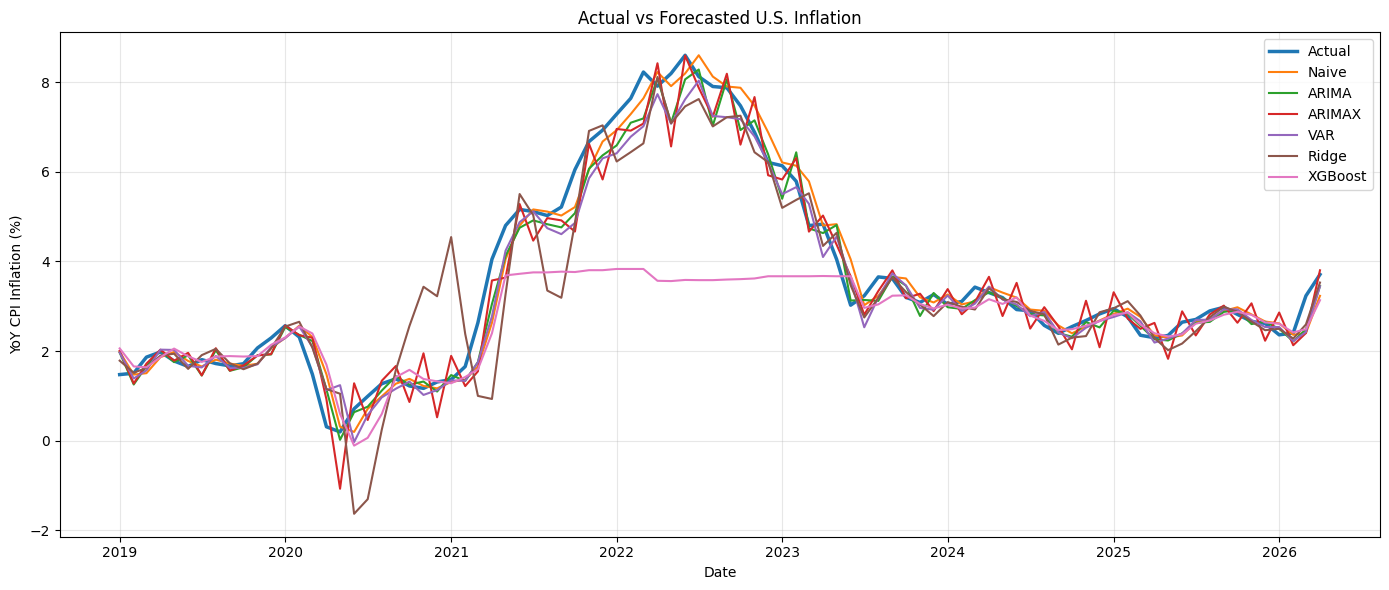

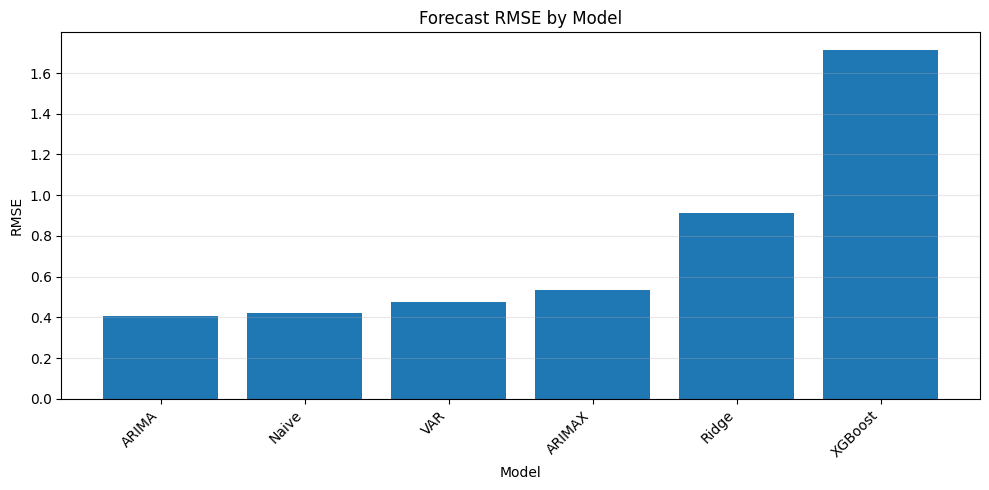

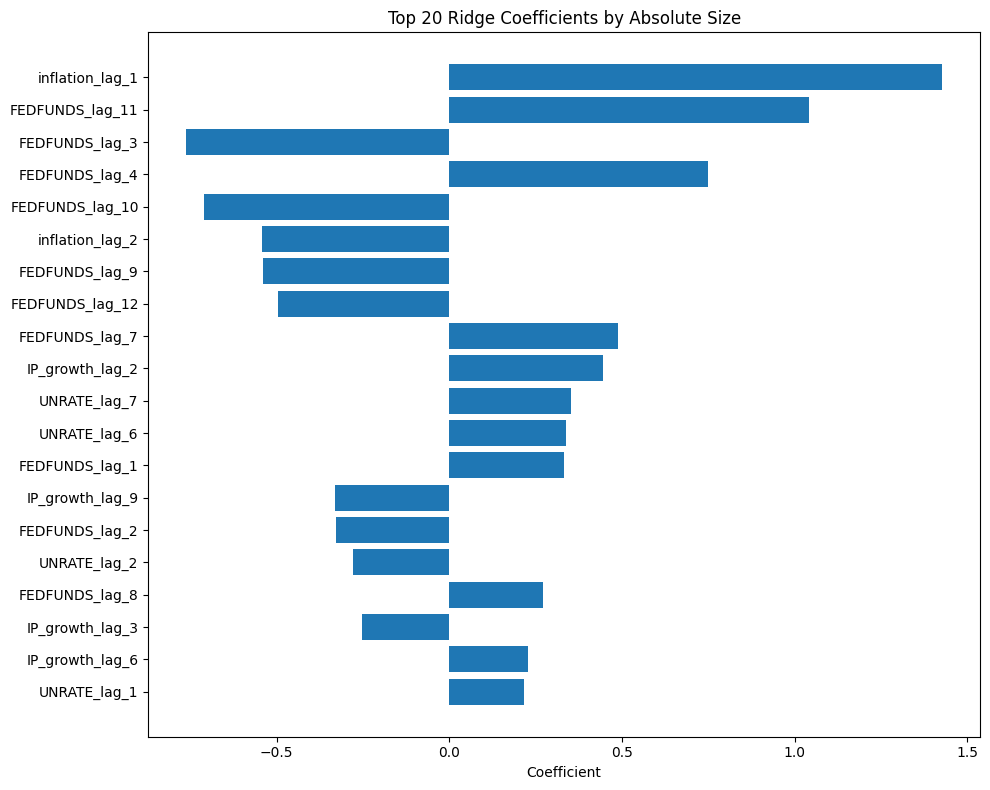

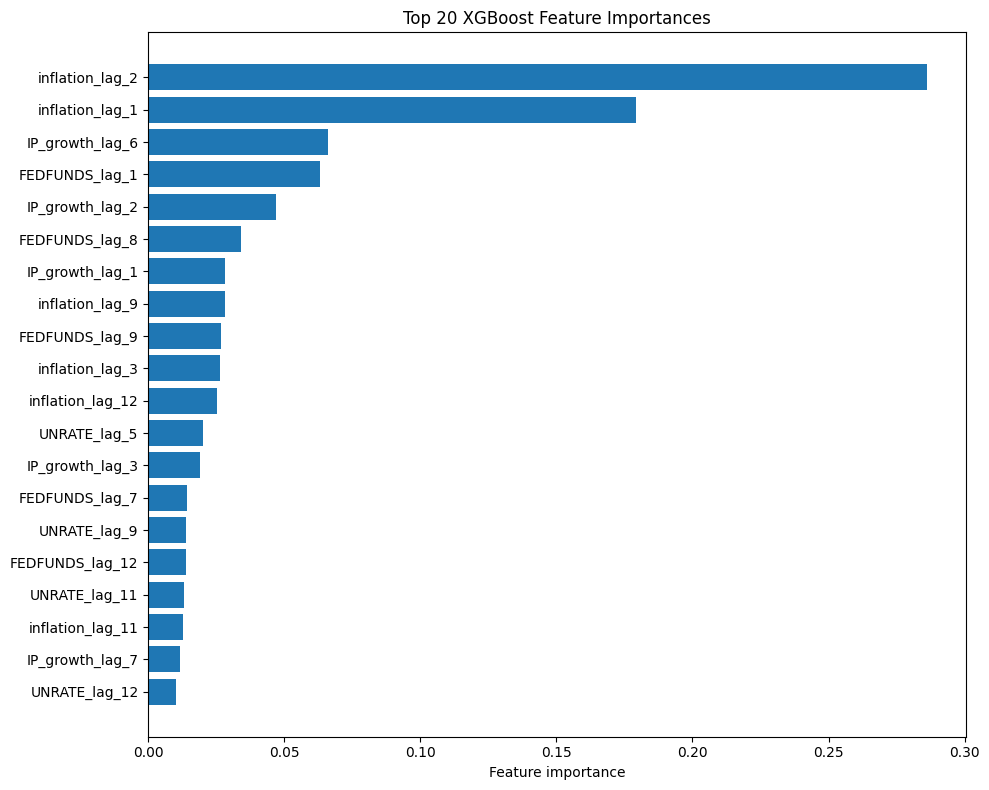

In [16]:
# =========================
# 12. Visualizations
# =========================

# Actual vs forecasts.
plot_cols = ["Naive", "ARIMA", "ARIMAX", "VAR", "Ridge"]
if "XGBoost" in forecast_df.columns:
    plot_cols.append("XGBoost")
plot_actual_vs_forecasts(forecast_df, plot_cols, "actual_vs_forecast_inflation.png")

# RMSE bar chart.
plt.figure(figsize=(10, 5))
plt.bar(performance["Model"], performance["RMSE"])
plt.title("Forecast RMSE by Model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "forecast_rmse_by_model.png", dpi=200)
plt.show()

# Ridge coefficient plot.
top_ridge = ridge_coef.head(20).iloc[::-1]
plt.figure(figsize=(10, 8))
plt.barh(top_ridge["feature"], top_ridge["coefficient"])
plt.title("Top 20 Ridge Coefficients by Absolute Size")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ridge_top_coefficients.png", dpi=200)
plt.show()

# XGBoost feature importance plot.
if XGBOOST_AVAILABLE and "xgb_importance" in globals():
    top_xgb = xgb_importance.head(20).iloc[::-1]
    plt.figure(figsize=(10, 8))
    plt.barh(top_xgb["feature"], top_xgb["importance"])
    plt.title("Top 20 XGBoost Feature Importances")
    plt.xlabel("Feature importance")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "xgboost_feature_importance.png", dpi=200)
    plt.show()

## Notes for report writing

Use these outputs for Section 5:

- `stationarity_tests.csv`: ADF and KPSS tests for the transformed variables.
- `acf_inflation.png` and `pacf_inflation.png`: target-series autocorrelation diagnostics.
- `arima_order_selection.csv`: ARIMA order selection by AIC.
- `residual_diagnostics.csv`: Ljung-Box residual autocorrelation diagnostics for ARIMA-family models.
- `var_stability_summary.csv` and `var_stability_roots.csv`: VAR stability diagnostics.
- `var_granger_results.csv`: Granger causality test for unemployment predicting inflation.
- `forecast_performance_results.csv`: main MAE/RMSE table.
- `forecast_performance_by_window.csv`: sub-period robustness results.
- `unemployment_comparison.csv`: comparison of models with vs without unemployment.
- `model_forecasts.csv`: actual and forecasted inflation series.
- `actual_vs_forecast_inflation.png`: main forecast plot.
- `forecast_rmse_by_model.png`: RMSE comparison plot.
- `ridge_top_coefficients.csv` and `ridge_top_coefficients.png`: Ridge feature interpretation.
- `xgboost_feature_importance.csv` and `xgboost_feature_importance.png`: XGBoost feature interpretation.
